# Graph neural network model for neonatal clinical indicators

## 1. Import libraries

In [1]:
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import torch
import torch.nn.functional as F
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_recall_curve, auc
import shap

## 2. Load the dataset

In [2]:
df = pd.read_csv('../../clinical_data/neonatal_processed.csv')
df.head()

,gestational_age_weeks,birth_weight_g,head_circumference_cm,delivery_mode,apgar_1min,apgar_5min,temperature_c,heart_rate_bpm,respiratory_rate_bpm,spo2_percent,primary_outcome
0,38.2,2730,37.0,0,9,10,36.7,147,48,96,0
1,39.8,2260,34.8,0,5,9,36.7,125,43,97,0
2,37.1,3030,39.4,0,9,9,36.4,120,47,97,0
3,39.7,3130,18.1,0,8,10,36.8,143,54,96,0
4,40.5,2870,34.1,0,8,7,37.2,108,46,97,0


## 3. Separate features and target variable

In [3]:
x = df.drop("primary_outcome", axis=1)
y = df["primary_outcome"]

## 4. Scale features

In [4]:
scaler = StandardScaler()
x = scaler.fit_transform(x)

## 5. Build graph

In [5]:
from sklearn.neighbors import NearestNeighbors

# Use NearestNeighbors for memory-efficient similarity computation
# Find k nearest neighbors for each sample
k = 5  # Each node connects to its 5 nearest neighbors
nbrs = NearestNeighbors(n_neighbors=k, algorithm='ball_tree').fit(x)
distances, indices = nbrs.kneighbors(x)

# Build edges from nearest neighbor connections
edges = []
for i in range(len(indices)):
    for j in indices[i]:
        if i != j:  # Avoid self-loops
            edges.append([i, j])

edge_index = np.array(edges).T if len(edges) > 0 else np.array([[], []]).T

print(f"Graph created with {len(edges)} edges")
print(f"Number of nodes: {len(x)}")

Graph created with 120000 edges
Number of nodes: 30000


### 5.1 Sample graph of 50 records

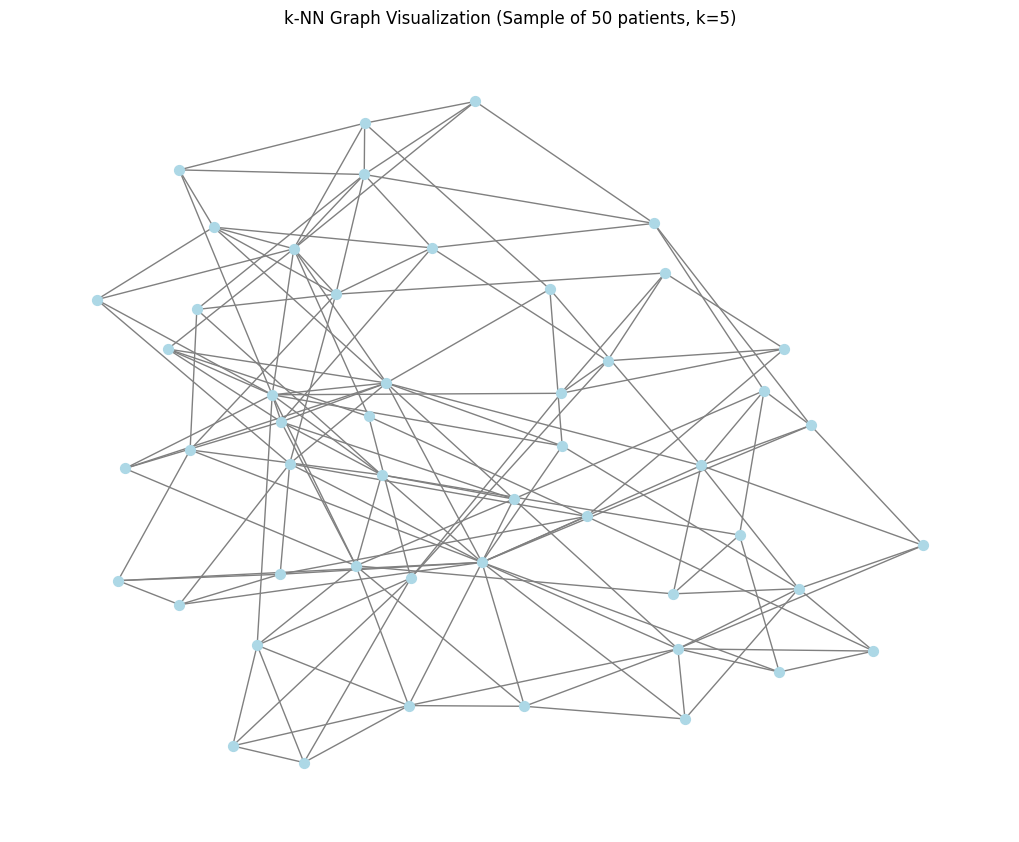

Graph has 50 nodes and 149 edges


In [18]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# Take a small sample (e.g., 50 patients)
sample_size = 50
sample_indices = np.random.choice(len(x), sample_size, replace=False)
x_sample = x[sample_indices]

# Build graph on the sample
k = 5
nbrs = NearestNeighbors(n_neighbors=k, algorithm='ball_tree').fit(x_sample)
distances, indices = nbrs.kneighbors(x_sample)

# Build edges
edges = []
for i in range(sample_size):
    for j in indices[i]:
        if i != j:
            edges.append((i, j))

# Create NetworkX graph
G = nx.Graph()
G.add_edges_from(edges)

# Draw
plt.figure(figsize=(10, 8))
nx.draw(G, node_size=50, node_color='lightblue', edge_color='gray', with_labels=False)
plt.title(f"k-NN Graph Visualization (Sample of {sample_size} patients, k={k})")
plt.savefig('gnn_graph_sample.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Graph has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")

### 5.2 Sample graph, n=100

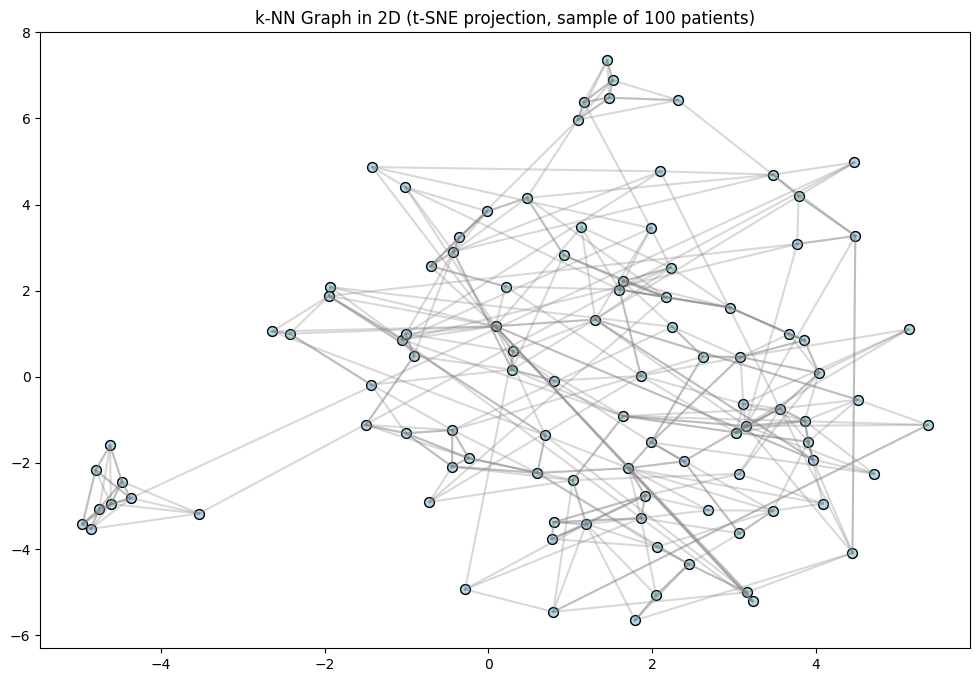

In [17]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Reduce dimensions to 2D for visualization
tsne = TSNE(n_components=2, random_state=42)
x_2d = tsne.fit_transform(x_sample)

# Plot points with edges
plt.figure(figsize=(12, 8))
for edge in edges:
    plt.plot([x_2d[edge[0], 0], x_2d[edge[1], 0]], 
             [x_2d[edge[0], 1], x_2d[edge[1], 1]], 'gray', alpha=0.3)

plt.scatter(x_2d[:, 0], x_2d[:, 1], c='lightblue', s=50, edgecolors='black')
plt.title(f"k-NN Graph in 2D (t-SNE projection, sample of {sample_size} patients)")
plt.savefig('gnn_tsne.png', dpi=300, bbox_inches='tight')
plt.show()

KeyboardInterrupt: 

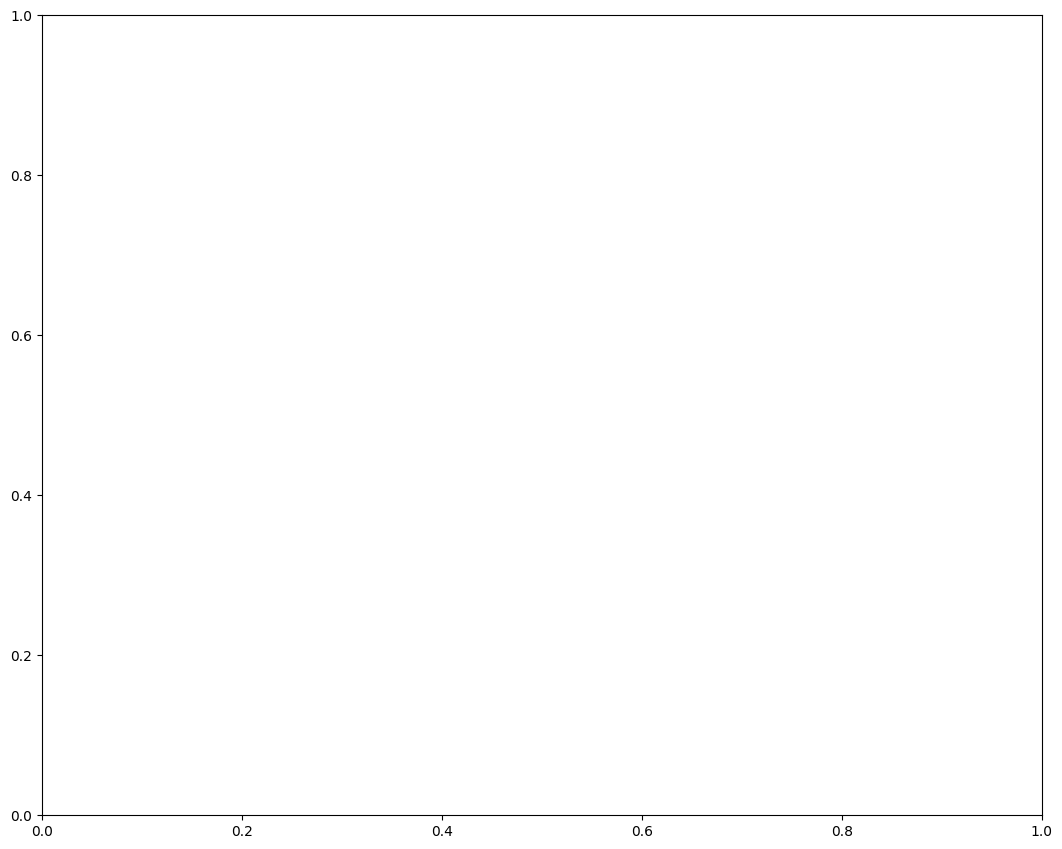

In [19]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# Take a small sample (e.g., 50 patients)
sample_size = 30000
sample_indices = np.random.choice(len(x), sample_size, replace=False)
x_sample = x[sample_indices]

# Build graph on the sample
k = 5
nbrs = NearestNeighbors(n_neighbors=k, algorithm='ball_tree').fit(x_sample)
distances, indices = nbrs.kneighbors(x_sample)

# Build edges
edges = []
for i in range(sample_size):
    for j in indices[i]:
        if i != j:
            edges.append((i, j))

# Create NetworkX graph
G = nx.Graph()
G.add_edges_from(edges)

# Draw
plt.figure(figsize=(10, 8))
nx.draw(G, node_size=30000, node_color='lightblue', edge_color='gray', with_labels=False)
plt.title(f"k-NN Graph Visualization (Sample of {sample_size} patients, k={k})")
plt.savefig('gnn_graph_sample.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Graph has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")

## 6. Convert to Pytorch Geometric format

In [6]:
x = torch.tensor(x, dtype=torch.float)
y = torch.tensor(y.values, dtype=torch.long)
edge_index = torch.tensor(edge_index, dtype=torch.long)

data = Data(x=x, edge_index=edge_index, y=y)

## 7. Split train and test data

In [7]:
# Create train/test split masks for node classification
from sklearn.model_selection import train_test_split

n_nodes = data.num_nodes
indices = np.arange(n_nodes)

# Split into train (80%) and test (20%)
train_indices, test_indices = train_test_split(indices, test_size=0.2, random_state=42)

# Create boolean masks
train_mask = torch.zeros(n_nodes, dtype=torch.bool)
test_mask = torch.zeros(n_nodes, dtype=torch.bool)

train_mask[train_indices] = True
test_mask[test_indices] = True

# Add masks to the data object
data.train_mask = train_mask
data.test_mask = test_mask

print(f"Training samples: {train_mask.sum().item()}")
print(f"Test samples: {test_mask.sum().item()}")

Training samples: 24000
Test samples: 6000


## 8. Define GNN model

In [8]:
class GNN(nn.Module):
    
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(GNN, self).__init__()
        
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, output_dim)

    def forward(self, data):
        
        x, edge_index = data.x, data.edge_index
        
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        
        x = self.conv2(x, edge_index)
        
        return F.log_softmax(x, dim=1)

## 9. Train model

In [9]:
model = GNN(input_dim=x.shape[1],
            hidden_dim=16,  # Reduced from 32 to save memory
            output_dim=2)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = torch.nn.NLLLoss()

for epoch in range(200):

    optimizer.zero_grad()

    out = model(data)

    # Only compute loss on training set
    loss = criterion(out[data.train_mask], data.y[data.train_mask])

    loss.backward()

    optimizer.step()

    print("Epoch:", epoch, "Loss:", loss.item())

Epoch: 0 Loss: 0.47665172815322876
Epoch: 1 Loss: 0.3939410448074341
Epoch: 2 Loss: 0.32852694392204285
Epoch: 3 Loss: 0.2788640260696411
Epoch: 4 Loss: 0.24142590165138245
Epoch: 5 Loss: 0.21247461438179016
Epoch: 6 Loss: 0.18919627368450165
Epoch: 7 Loss: 0.16974477469921112
Epoch: 8 Loss: 0.1530068814754486
Epoch: 9 Loss: 0.1383236199617386
Epoch: 10 Loss: 0.12532879412174225
Epoch: 11 Loss: 0.11373094469308853
Epoch: 12 Loss: 0.10347193479537964
Epoch: 13 Loss: 0.09449081122875214
Epoch: 14 Loss: 0.08677500486373901
Epoch: 15 Loss: 0.08027979731559753
Epoch: 16 Loss: 0.07493501901626587
Epoch: 17 Loss: 0.07065623253583908
Epoch: 18 Loss: 0.06726057827472687
Epoch: 19 Loss: 0.06450396776199341
Epoch: 20 Loss: 0.06215938925743103
Epoch: 21 Loss: 0.06004614755511284
Epoch: 22 Loss: 0.05804290249943733
Epoch: 23 Loss: 0.0560939647257328
Epoch: 24 Loss: 0.05419593304395676
Epoch: 25 Loss: 0.05238309130072594
Epoch: 26 Loss: 0.05070654675364494
Epoch: 27 Loss: 0.049212004989385605
Epoch:

## 10. Predictions

In [10]:
pred = model(data).argmax(dim=1)

# Get predictions and labels for test set
test_pred = pred[data.test_mask]
test_y = data.y[data.test_mask]

## 11. Evaluation

In [11]:
print(classification_report(test_y.numpy(), test_pred.detach().numpy()))
#PR_AUC evaluation
precision, recall, _ = precision_recall_curve(test_y, test_pred)
pr_auc = auc(recall, precision)
print(f"Precision-Recall AUC: {pr_auc:.4f}")

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      5838
           1       0.77      0.62      0.69       162

    accuracy                           0.98      6000
   macro avg       0.88      0.81      0.84      6000
weighted avg       0.98      0.98      0.98      6000

Precision-Recall AUC: 0.7023


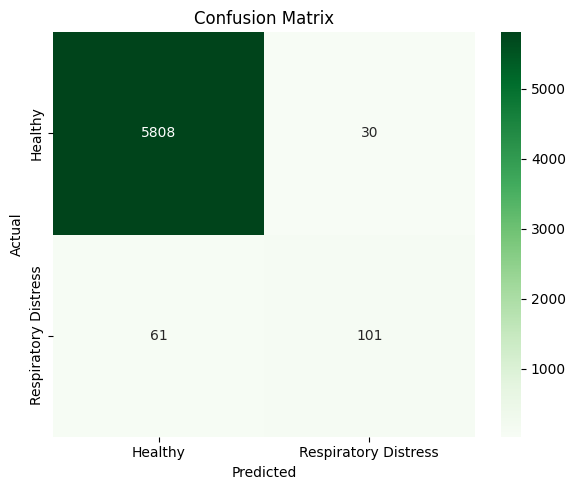

In [12]:
# Visualize confusion matrix
cm = confusion_matrix(test_y.numpy(), test_pred.detach().numpy())

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=True,
            xticklabels=['Healthy', 'Respiratory Distress'],
            yticklabels=['Healthy', 'Respiratory Distress'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## 12. Explainabilty

Top 10 Most Important Features:
 3. head_circumference_cm          - 0.482019
 8. heart_rate_bpm                 - 0.397500
 7. temperature_c                  - 0.368905
10. spo2_percent                   - 0.354721
 1. gestational_age_weeks          - 0.354287
 9. respiratory_rate_bpm           - 0.345637
 6. apgar_5min                     - 0.334019
 5. apgar_1min                     - 0.322384
 4. delivery_mode                  - 0.313536
 2. birth_weight_g                 - 0.256448


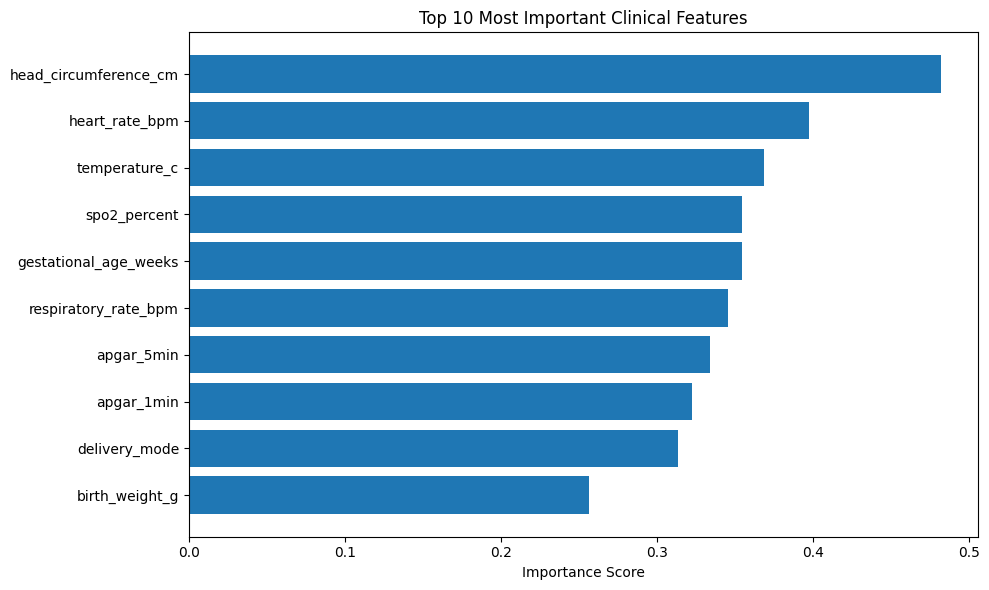

In [13]:
# Feature importance based on first layer weights
# GCNConv stores weights in lin.weight
feature_importance = model.conv1.lin.weight.data.abs().mean(dim=0).detach().numpy()

# Get feature names from the original dataframe (excluding target)
feature_names = df.drop("primary_outcome", axis=1).columns.tolist()

# Create a dataframe for visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("Top 10 Most Important Features:")
print("=" * 50)
for idx, row in importance_df.head(10).iterrows():
    print(f"{idx+1:2d}. {row['Feature']:30s} - {row['Importance']:.6f}")

plt.figure(figsize=(10, 6))
plt.barh(importance_df.head(10)['Feature'][::-1], importance_df.head(10)['Importance'][::-1])
plt.xlabel('Importance Score')
plt.title('Top 10 Most Important Clinical Features')
plt.tight_layout()
plt.show()


Top 10 Features by Correlation with Target (GNN-SHAP):
10. spo2_percent                   - 0.432068
 9. respiratory_rate_bpm           - 0.406376
 7. temperature_c                  - 0.290816
 1. gestational_age_weeks          - 0.285778
 2. birth_weight_g                 - 0.228191
 5. apgar_1min                     - 0.203522
 6. apgar_5min                     - 0.180081
 3. head_circumference_cm          - 0.049660
 4. delivery_mode                  - 0.042924
 8. heart_rate_bpm                 - 0.012181


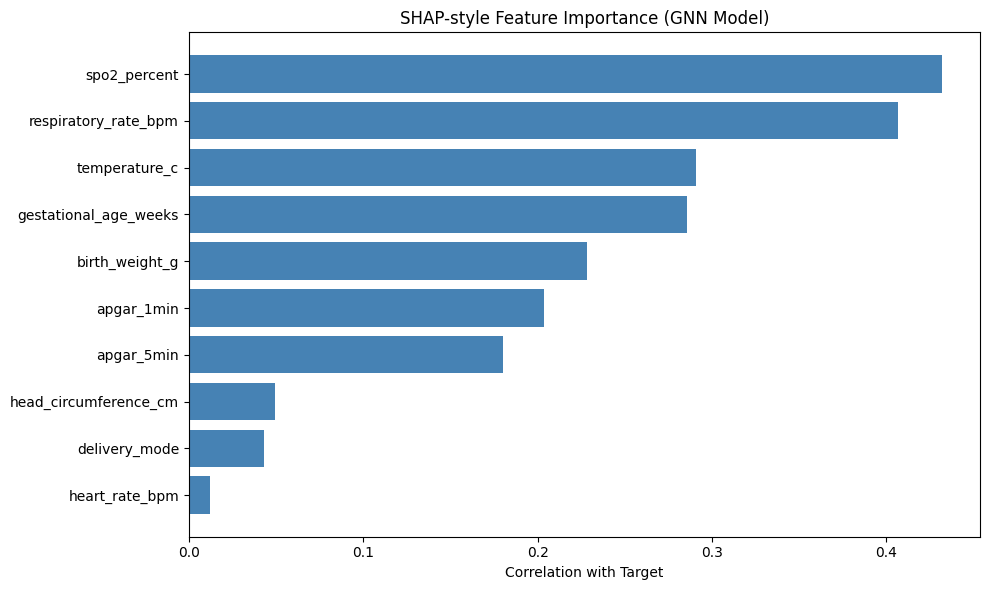

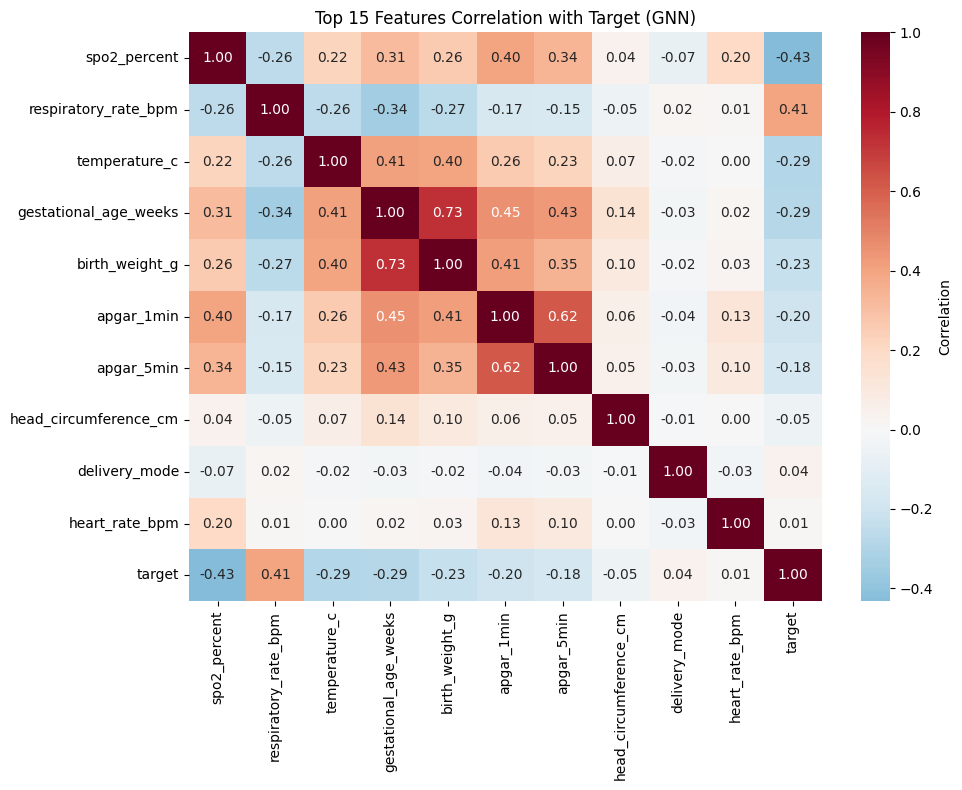

In [14]:
# Feature importance using correlation with target variable for GNN
# Get feature names from the original dataframe (excluding target)
feature_names = df.drop("primary_outcome", axis=1).columns.tolist()

# Create a dataframe with scaled features and target
combined_df = pd.DataFrame(x.numpy(), columns=feature_names)
combined_df['target'] = y.numpy()

# Calculate correlation of each feature with the target
correlations = combined_df.corr()['target'].drop('target').abs()

# Create a dataframe for visualization
importance_df_shap = pd.DataFrame({
    'Feature': feature_names,
    'SHAP_Importance': correlations.values
}).sort_values('SHAP_Importance', ascending=False)

print("Top 10 Features by Correlation with Target (GNN-SHAP):")
print("=" * 50)
for idx, row in importance_df_shap.head(10).iterrows():
    print(f"{idx+1:2d}. {row['Feature']:30s} - {row['SHAP_Importance']:.6f}")

# Visualize as bar plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df_shap.head(10)['Feature'][::-1], importance_df_shap.head(10)['SHAP_Importance'][::-1], color='steelblue')
plt.xlabel('Correlation with Target')
plt.title('SHAP-style Feature Importance (GNN Model)')
plt.tight_layout()
plt.show()

# Additional visualization: feature correlation heatmap
plt.figure(figsize=(10, 8))
top_features = importance_df_shap.head(15)['Feature'].tolist()
feature_corr = combined_df[top_features + ['target']].corr()
sns.heatmap(feature_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, cbar_kws={'label': 'Correlation'})
plt.title('Top 15 Features Correlation with Target (GNN)')
plt.tight_layout()
plt.show()